# FIT5149 Assessment 1: Report evidence and selected model

Group 43 | Aditya Palve and Eric Andres Acosta Ramirez

This is the notebook to use when checking the report. It brings together the calculations behind its tables and Figure 1. We kept the existing `final_clean` filename, but updated its contents from the earlier single CatBoost to our selected **attempt 4 two-stage CatBoost**.

The latest upload was attempt 5, not our selected model. It averaged three two-stage models and gave mixed validation results. Its public RMSE was also slightly worse. The smaller notebook `../FIT5149_A1_final.ipynb` remains the standalone implementation that produces attempt 4. The original analysis and attempt 5 notebooks are kept as development records.

## How to use this notebook

Select the environment with `requirements.txt` installed, restart the kernel, and run all cells in order. The main comparisons, final-model checks, tables and chart are calculated again from the supplied CSVs, not copied from saved notebook outputs. This takes several minutes because the models really are trained again.

| Report content | Notebook section |
|---|---|
| Data sizes, missing values, target groups, sentinels and corrupted age | 1 to 3 |
| Preprocessing comparisons | 4 to 7 |
| Candidate models and the two validation partitions | 8 to 12 |
| Correlations, permutation checks and Figure 1 | 3, 9 and 10 |
| Kaggle attempt table and public/internal differences | 14 |
| Matching the selected submission and software versions | 15 and 16 |

Section 13 clearly separates older experiment records from the results recalculated here. It includes an optional rerun of the broader search. Kaggle scores are external observations confirmed by the team, not scores we can recompute without the hidden test targets.

Outputs are saved in `../report/evidence/`. This notebook does not overwrite the Word/PDF report or any original Kaggle submission. The old `final_clean` is recoverable from Git commit `fc3a1ae` and a local backup in `.autosave_backup/`.

In [1]:
# Import the libraries and set reproducible defaults
from pathlib import Path
import os
import platform
import sys
import time
import warnings

# Limit parallel workers so the notebook remains stable on different machines
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Reuse the same seed and fold count in every experiment
RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

np.random.seed(RANDOM_STATE)

import ast
import hashlib
import json
import catboost
from catboost import CatBoostClassifier, CatBoostRegressor
from matplotlib.ticker import StrMethodFormatter

## 1. Load the data and protect our submitted files

The three input CSVs are in the repository root. We record their file fingerprints so we can tell if the inputs change. Output tables go into a separate evidence folder.

In [2]:
DATA_DIR = Path.cwd()
if not (DATA_DIR / "training_set.csv").exists():
    DATA_DIR = DATA_DIR.parent
assert (DATA_DIR / "training_set.csv").exists(), "Open this notebook from development/ or the repository root."

EVIDENCE_DIR = DATA_DIR / "report" / "evidence"
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

def file_hash(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_names = ["training_set.csv", "kaggle_test_X.csv", "sample_submission.csv"]
input_hashes = {name: file_hash(DATA_DIR / name) for name in input_names}
protected_paths = [DATA_DIR / "submission.csv", *sorted((DATA_DIR / "submissions").glob("submission*.csv"))]
protected_hashes = {str(path.relative_to(DATA_DIR)): file_hash(path) for path in protected_paths}

train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

# This helper displays and exports the same table, including its row labels.
report_tables = {}
def show_table(name, table):
    report_tables[name] = table.copy()
    table.to_csv(EVIDENCE_DIR / f"{name}.csv", index=True)
    display(table)

def rmse(actual, predicted):
    return float(mean_squared_error(actual, predicted) ** 0.5)

In [3]:
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

# Check that the files have the expected structure and ID order.
assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

# Read dates as day/month/year and stop if a value cannot be parsed.
train_dates = pd.to_datetime(
    train["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)
test_dates = pd.to_datetime(
    test["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)

integrity_checks = pd.Series({
    "training_rows": len(train),
    "test_rows": len(test),
    "duplicate_training_rows": int(train.duplicated().sum()),
    "duplicate_test_rows": int(test.duplicated().sum()),
    "duplicate_training_ids": int(train["application_id"].duplicated().sum()),
    "duplicate_test_ids": int(test["application_id"].duplicated().sum()),
    "shared_ids_between_train_and_test": int(
        train["application_id"].isin(test["application_id"]).sum()
    ),
    "training_date_min": train_dates.min().date(),
    "training_date_max": train_dates.max().date(),
    "test_date_min": test_dates.min().date(),
    "test_date_max": test_dates.max().date(),
})

print("All schema and identifier checks passed.")
display(integrity_checks)

assert not train["application_id"].isin(test["application_id"]).any()
assert train.duplicated().sum() == test.duplicated().sum() == 0
show_table("data_integrity", integrity_checks.rename("value").to_frame())

All schema and identifier checks passed.


training_rows                             19322
test_rows                                 10000
duplicate_training_rows                       0
duplicate_test_rows                           0
duplicate_training_ids                        0
duplicate_test_ids                            0
shared_ids_between_train_and_test             0
training_date_min                    2023-01-01
training_date_max                    2024-12-30
test_date_min                        2023-01-01
test_date_max                        2024-12-30
dtype: object

,value
training_rows,19322
test_rows,10000
duplicate_training_rows,0
duplicate_test_rows,0
duplicate_training_ids,0
duplicate_test_ids,0
shared_ids_between_train_and_test,0
training_date_min,2023-01-01
training_date_max,2024-12-30
test_date_min,2023-01-01


## 2. Understand the target

The target is an amount in AUD. Dividing it by the requested amount reveals the sanction-rate groups used in our validation. The observed rate is a target, never an input feature. We keep the zero cases because they are part of the prediction task.

In [4]:
# Keep the target separate from the input features.
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
requested_array = requested.to_numpy()

assert (requested > 0).all()

# The observed rates form the groups used to balance validation folds.
sanction_rate = (y / requested).round(2).astype(float)

target_checks = pd.Series({
    "zero_target_n": int((y == 0).sum()),
    "zero_target_pct": 100 * (y == 0).mean(),
    "sanction_above_request_n": int((y > requested).sum()),
    "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
})

display(target_checks)

assert y.between(0, requested).all()
show_table("target_checks", target_checks.rename("value").to_frame())
rate_counts = sanction_rate.value_counts().sort_index().rename("applications").to_frame()
rate_counts["percentage"] = 100 * rate_counts["applications"] / len(train)
show_table("sanction_rates", rate_counts)

zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

,value
zero_target_n,5177
zero_target_pct,26.793
sanction_above_request_n,0
unique_rounded_sanction_rates,"[0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]"


,applications,percentage
0.000,5177,26.793
0.650,3257,16.856
0.700,5686,29.428
0.750,2568,13.291
0.800,2502,12.949
0.850,42,0.217
0.900,50,0.259
1.000,40,0.207


## 3. Recreate the data-quality evidence

These tables explain the cleaning decisions in the report. Raw missing percentages count `NaN` only. We count the separate `-999` codes before replacing them. The property-age check compares overlapping rows directly, rather than relying on correlation alone.

The correlation table is descriptive. It does not show that a feature causes a loan to be approved.

In [5]:
SENTINEL_COLUMNS = ["existing_repayments_aud", "has_co_applicant", "property_value_aud"]
missing_columns_report = ["property_age_years", "monthly_income_aud", "annual_income_aud", "employment_sector", "credit_rating"]
missing_table = pd.DataFrame({
    "Train missing %": 100 * train[missing_columns_report].isna().mean(),
    "Test missing %": 100 * test[missing_columns_report].isna().mean(),
})
show_table("table_1_missing_values", missing_table)

sentinel_table = pd.DataFrame({
    "Train -999 count": (train[SENTINEL_COLUMNS] == -999).sum(),
    "Test -999 count": (test[SENTINEL_COLUMNS] == -999).sum(),
})
show_table("sentinel_codes", sentinel_table)

overlap = train[["property_age_years", "annual_income_aud"]].dropna()
age_checks = pd.Series({
    "overlapping_rows": len(overlap),
    "exact_matches": (overlap["property_age_years"] == overlap["annual_income_aud"]).sum(),
    "plausible_age_0_to_200": train["property_age_years"].between(0, 200).sum(),
}, name="rows")
show_table("property_age_checks", age_checks.to_frame())

clean_for_eda = train.replace({column: {-999: np.nan} for column in SENTINEL_COLUMNS})
correlations = clean_for_eda[["requested_amount_aud", "credit_rating", "has_co_applicant"]].corrwith(clean_for_eda[TARGET])
show_table("target_correlations", correlations.rename("Pearson correlation").to_frame())

,Train missing %,Test missing %
property_age_years,32.398,32.620
monthly_income_aud,25.686,24.840
annual_income_aud,25.091,24.850
employment_sector,24.356,24.190
credit_rating,20.459,21.330


,Train -999 count,Test -999 count
existing_repayments_aud,100,50
has_co_applicant,107,53
property_value_aud,199,110


,rows
overlapping_rows,11524
exact_matches,11524
plausible_age_0_to_200,0


,Pearson correlation
requested_amount_aud,0.740
credit_rating,0.375
has_co_applicant,0.269


## 4. Features used in the earlier comparisons

We keep the earlier feature-building code so the preprocessing comparisons can be repeated. It includes switches for testing ratios, missing flags and the possible income backup. This is comparison code, not a change to the selected model.

All these transformations work within one row. Imputation, encoding and scaling are fitted later, inside each training fold. The final CatBoost feature set is checked separately in section 9.

In [6]:
# Apply deterministic feature engineering shared by train and test
MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]


def engineer_comparison_features(
    frame,
    *,
    use_income_backup=False,
    add_business_features=True,
    add_missing_indicators=True,
):
    """Create row-wise features without learning information from other rows."""
    x = frame.copy()

    # Convert encoded missing values before counting or imputing them
    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    # Preserve missingness because the audit showed it may be informative
    x["missing_value_count"] = x.isna().sum(axis=1)
    if add_missing_indicators:
        for column in MISSING_INDICATOR_COLUMNS:
            x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    # Encode the date into trend and cyclical seasonal components
    application_date = pd.to_datetime(
        x.pop("application_date"), format="%d/%m/%Y", errors="raise"
    )
    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(2 * np.pi * application_date.dt.month / 12)
    x["application_month_cos"] = np.cos(2 * np.pi * application_date.dt.month / 12)
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    # Add affordability and security ratios motivated by lending logic
    if add_business_features:
        income_candidates = [x["annual_income_aud"], 12 * x["monthly_income_aud"]]
        # Test the corrupted property-age field only in the explicit ablation
        if use_income_backup:
            income_candidates.append(x["property_age_years"])
        income_candidates = pd.concat(income_candidates, axis=1)

        x["annual_income_reconciled_aud"] = income_candidates.median(axis=1, skipna=True)
        x["income_sources_available"] = income_candidates.notna().sum(axis=1)
        x["income_relative_gap"] = (
            (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
            / x["annual_income_reconciled_aud"].replace(0, np.nan)
        )
        x["requested_to_property_value"] = (
            x["requested_amount_aud"] / x["property_value_aud"].replace(0, np.nan)
        )
        x["requested_to_annual_income"] = (
            x["requested_amount_aud"]
            / x["annual_income_reconciled_aud"].replace(0, np.nan)
        )
        x["repayments_to_monthly_income"] = (
            x["existing_repayments_aud"]
            / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
        )
        x["property_value_minus_requested"] = (
            x["property_value_aud"] - x["requested_amount_aud"]
        )

    # Remove the row identifier and the corrupted property-age field
    x = x.drop(columns=["application_id", "property_age_years"])

    # Treat the repeated internal reference as a category, not a continuous number.
    x["property_ref"] = x["property_ref"].astype("string")
    return x


# Apply exactly the same deterministic transformations to both datasets
X = engineer_comparison_features(train.drop(columns=TARGET))
X_kaggle = engineer_comparison_features(test)

assert X.columns.tolist() == X_kaggle.columns.tolist()
assert not np.isinf(X.select_dtypes(include="number").to_numpy()).any()

print(f"Model matrix before learned preprocessing: {X.shape}")
print(f"Reconciled income remains missing for {X['annual_income_reconciled_aud'].isna().sum():,} rows")
X.head()

Model matrix before learned preprocessing: (19322, 50)
Reconciled income remains missing for 4,201 rows


,applicant_gender,applicant_age,annual_income_aud,income_consistency,occupation_class,employment_sector,residence_area,requested_amount_aud,existing_repayments_aud,expense_flag_a,expense_flag_b,dependants_count,credit_rating,prior_default_count,card_status,property_ref,property_category,property_area,has_co_applicant,property_value_aud,marketing_channel,branch_id,monthly_income_aud,risk_review_flag,enquiry_count_12m,missing_value_count,applicant_gender_is_missing,annual_income_aud_is_missing,income_consistency_is_missing,employment_sector_is_missing,existing_repayments_aud_is_missing,dependants_count_is_missing,credit_rating_is_missing,property_age_years_is_missing,property_area_is_missing,has_co_applicant_is_missing,property_value_aud_is_missing,monthly_income_aud_is_missing,application_year,application_month_sin,application_month_cos,application_dayofyear_sin,application_dayofyear_cos,annual_income_reconciled_aud,income_sources_available,income_relative_gap,requested_to_property_value,requested_to_annual_income,repayments_to_monthly_income,property_value_minus_requested
0,male,65,"3,572.420",steady,retiree,NaN,outer_metro,"80,823.310",369.810,no,yes,NaN,806.520,1,current,77,cat_c,NaN,1.000,"118,370.540",online,BR111,290.870,1,3,3,0,0,0,1,0,1,0,0,1,0,0,0,2024,-0.500,0.866,-0.497,0.868,"3,531.430",2,0.023,0.683,22.887,1.257,"37,547.230"
1,male,48,NaN,variable,salaried,retail,outer_metro,"41,673.080",188.250,no,no,2.000,613.700,1,current,743,cat_b,regional,0.000,"47,000.080",online,BR110,NaN,0,4,3,0,1,0,0,0,0,0,1,0,0,0,1,2023,-1.000,-0.000,-0.995,-0.102,NaN,0,NaN,0.887,NaN,NaN,"5,327.000"
2,female,18,"3,551.480",variable,salaried,retail,outer_metro,"199,076.750",941.270,no,yes,2.000,780.280,0,current,788,cat_b,outer_metro,1.000,"277,686.300",online,BR164,286.620,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,2024,-1.000,-0.000,-0.958,-0.287,"3,495.460",2,0.032,0.717,56.953,3.231,"78,609.550"
3,male,50,NaN,variable,commercial_partner,retail,inner_metro,"120,176.890",309.710,no,yes,2.000,NaN,0,none_held,709,cat_a,outer_metro,1.000,"203,173.220",online,BR051,NaN,1,3,4,0,1,0,0,0,0,1,1,0,0,0,1,2023,-0.500,-0.866,-0.391,-0.920,NaN,0,NaN,0.591,NaN,NaN,"82,996.330"
4,male,28,NaN,NaN,salaried,NaN,outer_metro,"62,745.530",454.490,no,no,NaN,NaN,0,current,772,cat_d,regional,1.000,"86,636.210",branch_walkin,BR072,NaN,1,2,7,0,1,1,1,0,1,1,1,0,0,0,1,2024,-0.000,1.000,-0.292,0.956,NaN,0,NaN,0.724,NaN,NaN,"23,890.680"


## 5. Use the same validation folds

Each row is predicted by a model that did not train on that row. We balance the folds by the eight sanction-rate groups and reuse the partitions across candidates. These are development scores used for comparison, not an untouched final test set.

In [7]:
# Create reproducible, target-tier-balanced validation folds
# The tier is used only for splitting and is never provided to the models
strata = sanction_rate.map(lambda value: f"{value:.2f}")
splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
# Materialise folds once so every candidate sees identical validation rows
folds = list(splitter.split(X, strata))

fold_balance = []
for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = strata.iloc[valid_index].value_counts(normalize=True).sort_index()
    fold_balance.append(counts.rename(f"fold_{fold_number}"))

pd.concat(fold_balance, axis=1).T.style.format("{:.2%}")

,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


In [8]:
# Save row membership so the partition can also be checked directly.
fold_ids = np.zeros(len(train), dtype=int)
for fold_number, (_, valid_index) in enumerate(folds, 1):
    fold_ids[valid_index] = fold_number
assert (fold_ids > 0).all()
pd.DataFrame({"application_id": train["application_id"], "fold": fold_ids}).to_csv(EVIDENCE_DIR / "fold_assignments.csv", index=False)

## 6. Recalculate the first model comparison

Ridge gives us a linear reference, Random Forest uses bagged trees, and HGB uses boosted trees. We keep the settings used in the original analysis. Predictions are clipped between zero and the requested amount for the report comparison.

In [9]:
# Build leakage-safe preprocessing and three model families
# Detect feature types after deterministic engineering
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

# Ridge needs scaled numeric values and one-hot encoded categories
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=10,
                            sparse_output=True,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

# Tree models use compact ordinal codes and tolerate nonlinear relationships
ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            max_categories=254,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

categorical_mask_after_ordinal = (
    [False] * len(numeric_features) + [True] * len(categorical_features)
)

# Compare a regularised linear reference model with two nonlinear tree approaches
models = {
    "Ridge": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=2,
                    max_features=0.8,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Histogram Gradient Boosting": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask_after_ordinal,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Candidate families:", ", ".join(models))

Numeric features: 37
Categorical features: 13
Candidate families: Ridge, Random Forest, Histogram Gradient Boosting


In [10]:
# Compare candidates with out-of-fold RMSE and MAE
# RMSE is the assignment/Kaggle selection metric
def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


validation_rows = []
oof_predictions = {}
requested_array = train["requested_amount_aud"].to_numpy()

# A simple underwriting heuristic provides a transparent reference point
heuristic_prediction = 0.70 * requested_array
print(
    "Simple 70% of requested heuristic: "
    f"RMSE ${rmse(y, heuristic_prediction):,.0f}; "
    f"MAE ${mean_absolute_error(y, heuristic_prediction):,.0f}"
)

for model_name, model in models.items():
    started = time.time()
    oof_raw = np.full(len(train), np.nan)
    oof_constrained = np.full(len(train), np.nan)

    # Refit the complete pipeline inside each fold to prevent leakage
    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(model)
        fitted_model.fit(X.iloc[train_index], y.iloc[train_index])

        raw_prediction = fitted_model.predict(X.iloc[valid_index])
        # Enforce the observed rule: 0 <= sanction <= requested amount
        constrained_prediction = np.clip(
            raw_prediction,
            0,
            requested_array[valid_index],
        )

        oof_raw[valid_index] = raw_prediction
        oof_constrained[valid_index] = constrained_prediction
        validation_rows.append(
            {
                "model": model_name,
                "fold": fold_number,
                "raw_rmse_aud": rmse(y.iloc[valid_index], raw_prediction),
                "constrained_rmse_aud": rmse(y.iloc[valid_index], constrained_prediction),
                "constrained_mae_aud": mean_absolute_error(
                    y.iloc[valid_index], constrained_prediction
                ),
                "prediction_below_zero_n": int((raw_prediction < 0).sum()),
                "prediction_above_request_n": int(
                    (raw_prediction > requested_array[valid_index]).sum()
                ),
            }
        )

    oof_predictions[model_name] = oof_constrained
    print(f"Finished {model_name} in {time.time() - started:.1f} seconds")

validation_detail = pd.DataFrame(validation_rows)
# Summarise both average performance and fold-to-fold stability
validation_summary = (
    validation_detail.groupby("model")
    .agg(
        mean_raw_rmse_aud=("raw_rmse_aud", "mean"),
        sd_raw_rmse_aud=("raw_rmse_aud", "std"),
        mean_constrained_rmse_aud=("constrained_rmse_aud", "mean"),
        sd_constrained_rmse_aud=("constrained_rmse_aud", "std"),
        mean_constrained_mae_aud=("constrained_mae_aud", "mean"),
        sd_constrained_mae_aud=("constrained_mae_aud", "std"),
        predictions_below_zero=("prediction_below_zero_n", "sum"),
        predictions_above_request=("prediction_above_request_n", "sum"),
    )
    .sort_values("mean_constrained_rmse_aud")
)

validation_summary.style.format(
    {
        "mean_raw_rmse_aud": "${:,.0f}",
        "sd_raw_rmse_aud": "${:,.0f}",
        "mean_constrained_rmse_aud": "${:,.0f}",
        "sd_constrained_rmse_aud": "${:,.0f}",
        "mean_constrained_mae_aud": "${:,.0f}",
        "sd_constrained_mae_aud": "${:,.0f}",
    }
)

Simple 70% of requested heuristic: RMSE $55,448; MAE $27,826


Finished Ridge in 1.1 seconds


Finished Random Forest in 19.2 seconds


Finished Histogram Gradient Boosting in 5.7 seconds


,mean_raw_rmse_aud,sd_raw_rmse_aud,mean_constrained_rmse_aud,sd_constrained_rmse_aud,mean_constrained_mae_aud,sd_constrained_mae_aud,predictions_below_zero,predictions_above_request
model,,,,,,,,
Random Forest,"$35,995","$1,447","$35,994","$1,447","$17,989",$540,0,7
Histogram Gradient Boosting,"$36,084","$1,281","$36,065","$1,283","$19,047",$624,205,233
Ridge,"$50,082","$13,099","$43,306",$887,"$27,868",$396,1397,959


In [11]:
initial_validation_detail = validation_detail.copy()
initial_validation_summary = validation_summary.copy()
show_table("initial_model_comparison", initial_validation_summary)
show_table("initial_model_folds", initial_validation_detail)

,mean_raw_rmse_aud,sd_raw_rmse_aud,mean_constrained_rmse_aud,sd_constrained_rmse_aud,mean_constrained_mae_aud,sd_constrained_mae_aud,predictions_below_zero,predictions_above_request
model,,,,,,,,
Random Forest,"35,994.548","1,446.932","35,994.206","1,447.047","17,988.566",540.358,0,7
Histogram Gradient Boosting,"36,084.116","1,280.609","36,064.809","1,283.085","19,047.285",624.005,205,233
Ridge,"50,082.491","13,098.634","43,305.644",887.392,"27,867.537",395.532,1397,959


,model,fold,raw_rmse_aud,constrained_rmse_aud,constrained_mae_aud,prediction_below_zero_n,prediction_above_request_n
0,Ridge,1,"43,290.184","42,214.079","27,186.682",283,217
1,Ridge,2,"45,220.273","44,147.719","28,017.374",298,179
2,Ridge,3,"73,465.641","43,652.356","28,140.955",276,199
3,Ridge,4,"43,522.407","42,507.260","27,870.177",269,195
4,Ridge,5,"44,913.950","44,006.805","28,122.494",271,169
5,Random Forest,1,"34,346.583","34,345.756","17,304.707",0,1
6,Random Forest,2,"36,772.752","36,772.752","18,240.727",0,0
7,Random Forest,3,"36,982.434","36,981.748","18,294.632",0,2
8,Random Forest,4,"34,508.921","34,508.835","17,534.113",0,2
9,Random Forest,5,"37,362.049","37,361.941","18,568.649",0,2


## 7. Check the preprocessing decisions

First we compare HGB with and without the extra features. Then we compare Random Forest with and without the internal property reference. The small differences should not be presented as strong evidence of an improvement.

In [12]:
# Test whether the engineered features improve validation performance
# Rebuild preprocessing because each ablation has a different feature set
def make_hgb_pipeline(feature_frame):
    categorical = feature_frame.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    numeric = [column for column in feature_frame.columns if column not in categorical]
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", SimpleImputer(strategy="median"), numeric),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                max_categories=254,
                            ),
                        ),
                    ]
                ),
                categorical,
            ),
        ]
    )
    categorical_mask = [False] * len(numeric) + [True] * len(categorical)
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


# Add transformations stepwise, including a deliberate test of the corrupt field
ablation_configurations = {
    "Cleaned raw features": {
        "use_income_backup": False,
        "add_business_features": False,
        "add_missing_indicators": False,
    },
    "+ ratios and missing indicators": {
        "use_income_backup": False,
        "add_business_features": True,
        "add_missing_indicators": True,
    },
    "+ property-age income backup": {
        "use_income_backup": True,
        "add_business_features": True,
        "add_missing_indicators": True,
    },
}

# Evaluate every configuration on the same folds for a fair comparison
ablation_rows = []
raw_predictors = train.drop(columns=TARGET)
for configuration_name, options in ablation_configurations.items():
    ablation_x = engineer_comparison_features(raw_predictors, **options)
    ablation_model = make_hgb_pipeline(ablation_x)

    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(ablation_model)
        fitted_model.fit(ablation_x.iloc[train_index], y.iloc[train_index])
        prediction = np.clip(
            fitted_model.predict(ablation_x.iloc[valid_index]),
            0,
            requested_array[valid_index],
        )
        ablation_rows.append(
            {
                "configuration": configuration_name,
                "fold": fold_number,
                "rmse_aud": rmse(y.iloc[valid_index], prediction),
                "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction),
                "feature_count": ablation_x.shape[1],
            }
        )

ablation_detail = pd.DataFrame(ablation_rows)
ablation_summary = (
    ablation_detail.groupby("configuration")
    .agg(
        feature_count=("feature_count", "first"),
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
        mean_mae_aud=("mae_aud", "mean"),
    )
    .sort_values("mean_rmse_aud")
)

# Report change relative to cleaned raw features; negative is an improvement
cleaned_raw_rmse = ablation_summary.loc["Cleaned raw features", "mean_rmse_aud"]
ablation_summary["rmse_change_vs_cleaned_raw_aud"] = (
    ablation_summary["mean_rmse_aud"] - cleaned_raw_rmse
)

ablation_summary.style.format(
    {
        "mean_rmse_aud": "${:,.0f}",
        "sd_rmse_aud": "${:,.0f}",
        "mean_mae_aud": "${:,.0f}",
        "rmse_change_vs_cleaned_raw_aud": "${:+,.0f}",
    }
)

,feature_count,mean_rmse_aud,sd_rmse_aud,mean_mae_aud,rmse_change_vs_cleaned_raw_aud
configuration,,,,,
+ ratios and missing indicators,50,"$36,065","$1,283","$19,047",$-46
+ property-age income backup,50,"$36,074","$1,319","$18,979",$-37
Cleaned raw features,31,"$36,111","$1,185","$19,087",$+0


In [13]:
# Compare the leading model with and without property_ref
X_without_property_ref = X.drop(columns=["property_ref"])
X_kaggle_without_property_ref = X_kaggle.drop(columns=["property_ref"])

# Rebuild the preprocessor because the selected feature set has one less category
selected_categorical_features = X_without_property_ref.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
selected_numeric_features = [
    column
    for column in X_without_property_ref.columns
    if column not in selected_categorical_features
]
selected_ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), selected_numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            max_categories=254,
                        ),
                    ),
                ]
            ),
            selected_categorical_features,
        ),
    ]
)
selected_categorical_mask = (
    [False] * len(selected_numeric_features)
    + [True] * len(selected_categorical_features)
)

property_ref_rows = [
    {
        "configuration": "With property_ref",
        "fold": int(row.fold),
        "rmse_aud": row.constrained_rmse_aud,
    }
    for row in validation_detail.loc[
        validation_detail["model"] == "Random Forest"
    ].itertuples()
]

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
    model_without_property_ref = Pipeline(
        steps=[
            ("preprocess", clone(selected_ordinal_preprocessor)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=2,
                    max_features=0.8,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model_without_property_ref.fit(
        X_without_property_ref.iloc[train_index], y.iloc[train_index]
    )
    prediction = np.clip(
        model_without_property_ref.predict(
            X_without_property_ref.iloc[valid_index]
        ),
        0,
        requested_array[valid_index],
    )
    property_ref_rows.append(
        {
            "configuration": "Without property_ref",
            "fold": fold_number,
            "rmse_aud": rmse(y.iloc[valid_index], prediction),
        }
    )

property_ref_detail = pd.DataFrame(property_ref_rows)
property_ref_summary = (
    property_ref_detail.groupby("configuration")
    .agg(
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
    )
    .sort_values("mean_rmse_aud")
)

# Use the simpler selected feature set in the remaining experiments
X_selected = X_without_property_ref
X_kaggle_selected = X_kaggle_without_property_ref

property_ref_summary.style.format("${:,.0f}")

,mean_rmse_aud,sd_rmse_aud
configuration,,
Without property_ref,"$35,956","$1,427"
With property_ref,"$35,994","$1,447"


In [14]:
show_table("hgb_feature_checks", ablation_summary)
show_table("property_reference_check", property_ref_summary)
preprocessing_table = pd.DataFrame({
    "Mean fold RMSE AUD": [
        ablation_summary.loc["Cleaned raw features", "mean_rmse_aud"],
        ablation_summary.loc["+ ratios and missing indicators", "mean_rmse_aud"],
        ablation_summary.loc["+ property-age income backup", "mean_rmse_aud"],
        property_ref_summary.loc["With property_ref", "mean_rmse_aud"],
        property_ref_summary.loc["Without property_ref", "mean_rmse_aud"],
    ]
}, index=["HGB cleaned raw features", "HGB ratios and missing flags", "HGB property-age income backup", "RF with property_ref", "RF without property_ref"])
show_table("table_2_preprocessing", preprocessing_table)

,feature_count,mean_rmse_aud,sd_rmse_aud,mean_mae_aud,rmse_change_vs_cleaned_raw_aud
configuration,,,,,
+ ratios and missing indicators,50,"36,064.809","1,283.085","19,047.285",-46.142
+ property-age income backup,50,"36,073.800","1,319.347","18,978.718",-37.151
Cleaned raw features,31,"36,110.951","1,184.597","19,086.756",0.000


,mean_rmse_aud,sd_rmse_aud
configuration,,
Without property_ref,"35,955.755","1,427.051"
With property_ref,"35,994.206","1,447.047"


,Mean fold RMSE AUD
HGB cleaned raw features,"36,110.951"
HGB ratios and missing flags,"36,064.809"
HGB property-age income backup,"36,073.800"
RF with property_ref,"35,994.206"
RF without property_ref,"35,955.755"


## 8. Recalculate the target-aware HGB models

We try predicting the sanctioned share instead of the dollar amount directly. For the tier classifier, the expected rate keeps uncertainty by averaging rates with their predicted probabilities. A hard tier chooses just one class. The hard version has lower MAE but worse RMSE, so it is not our selected model.

In [15]:
# Attempt 2: target-aware sanction-rate regression

rate_target = sanction_rate.astype(float)

# Compare ordinary rate prediction with an RMSE-aligned weighted version
rate_model_results = []
rate_oof_predictions = {}

rate_models = {
    "Rate HGB": False,
    "Rate HGB weighted": True,
}

for model_name, use_weights in rate_models.items():
    started = time.time()
    oof_prediction = np.full(len(train), np.nan)

    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):

        model = Pipeline(
            steps=[
                ("preprocess", clone(selected_ordinal_preprocessor)),
                (
                    "model",
                    HistGradientBoostingRegressor(
                        max_iter=400,
                        learning_rate=0.05,
                        max_leaf_nodes=31,
                        min_samples_leaf=20,
                        l2_regularization=1.0,
                        categorical_features=selected_categorical_mask,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )

        fit_kwargs = {}

        if use_weights:
            # Dollar RMSE from a rate error scales with requested_amount^2.
            # Normalise weights so their average remains around one.
            fold_requested = requested_array[train_index]
            weights = fold_requested ** 2
            weights = weights / weights.mean()

            fit_kwargs["model__sample_weight"] = weights

        model.fit(
            X_selected.iloc[train_index],
            rate_target.iloc[train_index],
            **fit_kwargs,
        )

        predicted_rate = model.predict(
            X_selected.iloc[valid_index]
        )

        predicted_rate = np.clip(
            predicted_rate,
            0,
            1,
        )

        predicted_amount = (
            predicted_rate
            * requested_array[valid_index]
        )

        predicted_amount = np.clip(
            predicted_amount,
            0,
            requested_array[valid_index],
        )

        oof_prediction[valid_index] = predicted_amount

        rate_model_results.append(
            {
                "model": model_name,
                "fold": fold_number,
                "rmse_aud": rmse(
                    y.iloc[valid_index],
                    predicted_amount,
                ),
                "mae_aud": mean_absolute_error(
                    y.iloc[valid_index],
                    predicted_amount,
                ),
            }
        )

    rate_oof_predictions[model_name] = oof_prediction

    print(
        f"Finished {model_name} in "
        f"{time.time() - started:.1f} seconds"
    )


rate_validation_detail = pd.DataFrame(rate_model_results)

rate_validation_summary = (
    rate_validation_detail
    .groupby("model")
    .agg(
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
        mean_mae_aud=("mae_aud", "mean"),
    )
    .sort_values("mean_rmse_aud")
)

rate_validation_summary.style.format(
    {
        "mean_rmse_aud": "${:,.0f}",
        "sd_rmse_aud": "${:,.0f}",
        "mean_mae_aud": "${:,.0f}",
    }
)

Finished Rate HGB in 5.6 seconds


Finished Rate HGB weighted in 8.7 seconds


,mean_rmse_aud,sd_rmse_aud,mean_mae_aud
model,,,
Rate HGB,"$34,812","$1,281","$17,416"
Rate HGB weighted,"$35,670","$1,293","$17,437"


In [16]:
# Attempt 2B: predict the observed sanction tiers as discrete classes

SANCTION_TIERS = np.array([
    0.00,
    0.65,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90,
    1.00,
])

# Convert each observed sanction rate to the nearest tier ID: 0, 1, ..., 7
tier_target = pd.Series(
    np.abs(
        sanction_rate.to_numpy()[:, None]
        - SANCTION_TIERS[None, :]
    ).argmin(axis=1),
    index=sanction_rate.index,
    dtype=int,
)

# Quick check
print("Tier mapping:")
print(
    pd.DataFrame({
        "rate": sanction_rate,
        "tier_id": tier_target,
    })
    .groupby("tier_id")
    .agg(
        count=("rate", "size"),
        observed_rate=("rate", "mean"),
    )
)

tier_rows = []

tier_oof_soft = np.full(len(train), np.nan)
tier_oof_hard = np.full(len(train), np.nan)

started = time.time()

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):

    tier_model = Pipeline(
        steps=[
            ("preprocess", clone(selected_ordinal_preprocessor)),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_iter=400,
                    learning_rate=0.05,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=selected_categorical_mask,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    tier_model.fit(
        X_selected.iloc[train_index],
        tier_target.iloc[train_index],
    )

    validation_x = X_selected.iloc[valid_index]

    # -------------------------
    # Soft / expected-rate prediction
    # -------------------------

    probabilities = tier_model.predict_proba(validation_x)

    class_ids = (
        tier_model.named_steps["model"]
        .classes_
        .astype(int)
    )

    class_rates = SANCTION_TIERS[class_ids]

    predicted_rate_soft = probabilities @ class_rates

    predicted_amount_soft = (
        predicted_rate_soft
        * requested_array[valid_index]
    )

    predicted_amount_soft = np.clip(
        predicted_amount_soft,
        0,
        requested_array[valid_index],
    )

    # -------------------------
    # Hard tier prediction
    # -------------------------

    predicted_class_ids = tier_model.predict(
        validation_x
    ).astype(int)

    predicted_rate_hard = SANCTION_TIERS[
        predicted_class_ids
    ]

    predicted_amount_hard = (
        predicted_rate_hard
        * requested_array[valid_index]
    )

    predicted_amount_hard = np.clip(
        predicted_amount_hard,
        0,
        requested_array[valid_index],
    )

    tier_oof_soft[valid_index] = predicted_amount_soft
    tier_oof_hard[valid_index] = predicted_amount_hard

    tier_rows.extend(
        [
            {
                "model": "Tier HGB - expected rate",
                "fold": fold_number,
                "rmse_aud": rmse(
                    y.iloc[valid_index],
                    predicted_amount_soft,
                ),
                "mae_aud": mean_absolute_error(
                    y.iloc[valid_index],
                    predicted_amount_soft,
                ),
            },
            {
                "model": "Tier HGB - hard tier",
                "fold": fold_number,
                "rmse_aud": rmse(
                    y.iloc[valid_index],
                    predicted_amount_hard,
                ),
                "mae_aud": mean_absolute_error(
                    y.iloc[valid_index],
                    predicted_amount_hard,
                ),
            },
        ]
    )

print(
    f"\nFinished tier-aware HGB in "
    f"{time.time() - started:.1f} seconds"
)

tier_validation_detail = pd.DataFrame(tier_rows)

tier_validation_summary = (
    tier_validation_detail
    .groupby("model")
    .agg(
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
        mean_mae_aud=("mae_aud", "mean"),
    )
    .sort_values("mean_rmse_aud")
)

tier_validation_summary.style.format(
    {
        "mean_rmse_aud": "${:,.0f}",
        "sd_rmse_aud": "${:,.0f}",
        "mean_mae_aud": "${:,.0f}",
    }
)

Tier mapping:
         count  observed_rate
tier_id                      
0         5177          0.000
1         3257          0.650
2         5686          0.700
3         2568          0.750
4         2502          0.800
5           42          0.850
6           50          0.900
7           40          1.000



Finished tier-aware HGB in 32.2 seconds


,mean_rmse_aud,sd_rmse_aud,mean_mae_aud
model,,,
Tier HGB - expected rate,"$34,658","$1,374","$17,162"
Tier HGB - hard tier,"$39,459","$2,455","$14,425"


In [17]:
show_table("rate_hgb_comparison", rate_validation_summary)
show_table("tier_hgb_comparison", tier_validation_summary)

,mean_rmse_aud,sd_rmse_aud,mean_mae_aud
model,,,
Rate HGB,"34,812.024","1,281.480","17,416.239"
Rate HGB weighted,"35,670.405","1,293.011","17,436.861"


,mean_rmse_aud,sd_rmse_aud,mean_mae_aud
model,,,
Tier HGB - expected rate,"34,658.376","1,374.217","17,161.762"
Tier HGB - hard tier,"39,458.867","2,454.957","14,424.703"


## 9. Fit and check the selected attempt 4 model

We now use the same cleaning, predictor order, parameters and functions as `../FIT5149_A1_final.ipynb`. The two stages answer different questions:

1. How likely is the application to receive a positive amount?
2. If approved, what share of the request is likely to be sanctioned?

The expected amount is `requested amount * approval probability * positive sanction rate`. Both stages use only the fitting rows during validation. We keep the probabilities rather than forcing a yes/no decision at 0.5.

This section trains the selected model again and repeats the five-input permutation check. No saved validation JSON supplies the numbers below.

In [18]:
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

# Use the same missing-value indicator columns for training and test data.
MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]

def engineer_features(frame):
    x = frame.copy()

    # The EDA showed that -999 means missing in these three columns.
    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    # Keep a count and yes/no flags, since missing information may be useful.
    x["missing_value_count"] = x.isna().sum(axis=1)

    for column in MISSING_INDICATOR_COLUMNS:
        x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    # Represent the calendar without treating December and January as far apart.
    application_date = pd.to_datetime(
        x.pop("application_date"),
        format="%d/%m/%Y",
        errors="raise",
    )

    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_month_cos"] = np.cos(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    # Put both income fields on an annual scale, then combine them within each row.
    income_candidates = pd.concat(
        [
            x["annual_income_aud"],
            12 * x["monthly_income_aud"],
        ],
        axis=1,
    )

    x["annual_income_reconciled_aud"] = income_candidates.median(
        axis=1,
        skipna=True,
    )
    x["income_sources_available"] = income_candidates.notna().sum(axis=1)

    # Record disagreement between the two reported income values.
    x["income_relative_gap"] = (
        (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    # Compare loan size with income and property value.
    # Replace zero denominators with missing values to avoid division by zero.
    x["requested_to_property_value"] = (
        x["requested_amount_aud"]
        / x["property_value_aud"].replace(0, np.nan)
    )

    x["requested_to_annual_income"] = (
        x["requested_amount_aud"]
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    x["repayments_to_monthly_income"] = (
        x["existing_repayments_aud"]
        / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
    )

    x["property_value_minus_requested"] = (
        x["property_value_aud"] - x["requested_amount_aud"]
    )

    # Drop IDs and the unreliable property-age values identified in the EDA.
    # Its missing-value flag is kept; property_ref was excluded during development.
    x = x.drop(
        columns=[
            "application_id",
            "property_age_years",
            "property_ref",
        ]
    )

    return x

X_selected = engineer_features(train.drop(columns=TARGET))
X_kaggle_selected = engineer_features(test)

assert X_selected.columns.tolist() == X_kaggle_selected.columns.tolist()
assert not np.isinf(
    X_selected.select_dtypes(include="number").to_numpy()
).any()

selected_categorical_features = (
    X_selected
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

# Give missing categories a label that CatBoost can read.
# Numeric gaps stay as NaN.
for column in selected_categorical_features:
    X_selected[column] = (
        X_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

    X_kaggle_selected[column] = (
        X_kaggle_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

print(f"Final predictor count: {X_selected.shape[1]}")
print(f"Categorical predictors: {len(selected_categorical_features)}")

Final predictor count: 49
Categorical predictors: 12


In [19]:
# These are the settings used for attempt 4. No tuning happens in this notebook.
MODEL_NAME = 'catboost_two_stage'
MODEL_PARAMS = {
    "depth": 5,
    "iterations": 1200,
    "learning_rate": 0.03,
    "l2_leaf_reg": 10.0,
    "random_seed": 42,
    "thread_count": 6,
    "verbose": False,
    "allow_writing_files": False,
}

# Keep the exact predictor names and order used in attempt 4.
PREDICTOR_COLUMNS = [
    "applicant_gender",
    "applicant_age",
    "annual_income_aud",
    "income_consistency",
    "occupation_class",
    "employment_sector",
    "residence_area",
    "requested_amount_aud",
    "existing_repayments_aud",
    "expense_flag_a",
    "expense_flag_b",
    "dependants_count",
    "credit_rating",
    "prior_default_count",
    "card_status",
    "property_category",
    "property_area",
    "has_co_applicant",
    "property_value_aud",
    "marketing_channel",
    "branch_id",
    "monthly_income_aud",
    "risk_review_flag",
    "enquiry_count_12m",
    "missing_value_count",
    "applicant_gender_is_missing",
    "annual_income_aud_is_missing",
    "income_consistency_is_missing",
    "employment_sector_is_missing",
    "existing_repayments_aud_is_missing",
    "dependants_count_is_missing",
    "credit_rating_is_missing",
    "property_age_years_is_missing",
    "property_area_is_missing",
    "has_co_applicant_is_missing",
    "property_value_aud_is_missing",
    "monthly_income_aud_is_missing",
    "application_year",
    "application_month_sin",
    "application_month_cos",
    "application_dayofyear_sin",
    "application_dayofyear_cos",
    "annual_income_reconciled_aud",
    "income_sources_available",
    "income_relative_gap",
    "requested_to_property_value",
    "requested_to_annual_income",
    "repayments_to_monthly_income",
    "property_value_minus_requested",
]
MODEL_CATEGORIES = [c for c in selected_categorical_features if c in PREDICTOR_COLUMNS]

def fit_final_model(features, amounts):
    # During validation, these are only the training rows for the current fold.
    requested_amounts = features["requested_amount_aud"].to_numpy()
    rates = (np.asarray(amounts) / requested_amounts).round(2)
    approved = np.asarray(amounts) > 0
    predictors = features[PREDICTOR_COLUMNS]

    # 1. Learn whether an application receives a positive amount.
    approval_model = CatBoostClassifier(loss_function="Logloss", **MODEL_PARAMS)
    approval_model.fit(predictors, approved.astype(int), cat_features=MODEL_CATEGORIES)

    # 2. Learn the approved share using positive cases only.
    rate_params = dict(MODEL_PARAMS, depth=4, iterations=800)
    rate_model = CatBoostRegressor(loss_function="RMSE", **rate_params)
    rate_model.fit(predictors.loc[approved], rates[approved], cat_features=MODEL_CATEGORIES)
    return approval_model, rate_model


def predict_final_model(models, features):
    approval_model, rate_model = models
    predictors = features[PREDICTOR_COLUMNS]
    # Find the probability column for approval (class 1).
    positive_column = list(approval_model.classes_).index(1)
    approval_probability = approval_model.predict_proba(predictors)[:, positive_column]
    positive_rate = np.clip(rate_model.predict(predictors), 0, 1)
    requested_amounts = features["requested_amount_aud"].to_numpy()
    # 3. Convert the two estimates into an expected amount in AUD.
    prediction = requested_amounts * approval_probability * positive_rate
    # Training amounts were never negative or above the requested loan.
    return np.clip(prediction, 0, requested_amounts)

In [20]:
# Check that the visible final-model code has not drifted from the standalone notebook.
# This reads source text for comparison only; it does not execute another notebook.
def notebook_function(path, name):
    notebook = json.loads(path.read_text())
    for cell in notebook["cells"]:
        if cell["cell_type"] != "code":
            continue
        for node in ast.parse("".join(cell["source"])).body:
            if isinstance(node, ast.FunctionDef) and node.name == name:
                return ast.dump(node, include_attributes=False)
    raise AssertionError(f"Function not found: {name}")

root_notebook = DATA_DIR / "FIT5149_A1_final.ipynb"
this_notebook = DATA_DIR / "development" / "FIT5149_A1_final_clean.ipynb"
for function_name in ["engineer_features", "fit_final_model", "predict_final_model"]:
    assert notebook_function(this_notebook, function_name) == notebook_function(root_notebook, function_name)
assert X_selected.shape[1] == 49 and len(MODEL_CATEGORIES) == 12
print("The three final-model functions match the standalone implementation.")

model_settings = pd.DataFrame([
    dict(stage="Approval", loss="Logloss", depth=5, iterations=1200, learning_rate=0.03, l2_leaf_reg=10, seed=42),
    dict(stage="Positive rate", loss="RMSE", depth=4, iterations=800, learning_rate=0.03, l2_leaf_reg=10, seed=42),
]).set_index("stage")
show_table("final_model_settings", model_settings)
show_table("final_predictors", pd.DataFrame({"feature": PREDICTOR_COLUMNS, "categorical": [c in MODEL_CATEGORIES for c in PREDICTOR_COLUMNS]}))

The three final-model functions match the standalone implementation.


,loss,depth,iterations,learning_rate,l2_leaf_reg,seed
stage,,,,,,
Approval,Logloss,5,1200,0.030,10,42
Positive rate,RMSE,4,800,0.030,10,42


,feature,categorical
0,applicant_gender,True
1,applicant_age,False
2,annual_income_aud,False
3,income_consistency,True
4,occupation_class,True
5,employment_sector,True
6,residence_area,True
7,requested_amount_aud,False
8,existing_repayments_aud,False
9,expense_flag_a,True


In [21]:
validation_rows = []
permutation_rows = []
# OOF stores one held-out prediction for every training application.
final_oof = np.full(len(train), np.nan)
FEATURES_TO_CHECK = [
    "requested_amount_aud", "has_co_applicant", "credit_rating",
    "income_consistency", "applicant_age",
]
started = time.time()

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
    # Fit on this fold's training rows, then predict its held-out rows.
    fitted_model = fit_final_model(X_selected.iloc[train_index], y.iloc[train_index])
    validation_x = X_selected.iloc[valid_index]
    prediction = predict_final_model(fitted_model, validation_x)
    final_oof[valid_index] = prediction
    fold_rmse = rmse(y.iloc[valid_index], prediction)
    validation_rows.append({
        "fold": fold_number,
        "rmse_aud": fold_rmse,
        "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction),
    })
    print(f"Fold {fold_number}: RMSE ${fold_rmse:,.2f}")

    # Shuffle validation inputs only. Do not refit the model for this check.
    for feature_number, feature in enumerate(FEATURES_TO_CHECK):
        for repeat in range(3):
            shuffled = validation_x.copy()
            # Give each shuffle a different but repeatable seed.
            rng = np.random.default_rng(
                RANDOM_STATE + 1000 * fold_number + 10 * feature_number + repeat
            )
            shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
            shuffled_prediction = predict_final_model(fitted_model, shuffled)
            permutation_rows.append({
                "feature": feature, "fold": fold_number, "repeat": repeat + 1,
                "rmse_increase_aud": rmse(y.iloc[valid_index], shuffled_prediction) - fold_rmse,
            })

# Make sure every row received a valid held-out prediction.
assert np.isfinite(final_oof).all()
validation_detail = pd.DataFrame(validation_rows)
validation_summary = pd.Series({
    "mean_fold_rmse_aud": validation_detail["rmse_aud"].mean(),
    "sd_fold_rmse_aud": validation_detail["rmse_aud"].std(),
    "global_oof_rmse_aud": rmse(y, final_oof),
    "mae_aud": mean_absolute_error(y, final_oof),
    "validation_seconds": time.time() - started,
})
permutation_detail = pd.DataFrame(permutation_rows)
# Average the three shuffles within each fold before comparing folds.
permutation_by_fold = (
    permutation_detail.groupby(["feature", "fold"])["rmse_increase_aud"].mean()
)
permutation_summary = (
    permutation_by_fold.groupby("feature")
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)
display(validation_summary)
display(permutation_summary)

Fold 1: RMSE $32,393.77


Fold 2: RMSE $34,388.31


Fold 3: RMSE $34,920.65


Fold 4: RMSE $33,013.18


Fold 5: RMSE $35,077.95


mean_fold_rmse_aud    33,958.773
sd_fold_rmse_aud       1,194.324
global_oof_rmse_aud   33,975.512
mae_aud               16,850.524
validation_seconds        54.340
dtype: float64

,mean,std
feature,,
requested_amount_aud,"51,198.693","1,842.106"
credit_rating,"20,197.501","1,872.842"
has_co_applicant,"17,953.143",903.864
income_consistency,"1,355.691",489.275
applicant_age,59.876,40.817


In [22]:
show_table("final_validation_folds", validation_detail)
show_table("final_validation_summary", validation_summary.rename("value").to_frame())
show_table("table_5_permutation", permutation_summary)
show_table("permutation_repeats", permutation_detail)

,fold,rmse_aud,mae_aud
0,1,"32,393.770","16,142.532"
1,2,"34,388.312","17,043.382"
2,3,"34,920.653","17,130.083"
3,4,"33,013.184","16,508.236"
4,5,"35,077.948","17,428.521"


,value
mean_fold_rmse_aud,"33,958.773"
sd_fold_rmse_aud,"1,194.324"
global_oof_rmse_aud,"33,975.512"
mae_aud,"16,850.524"
validation_seconds,54.340


,mean,std
feature,,
requested_amount_aud,"51,198.693","1,842.106"
credit_rating,"20,197.501","1,872.842"
has_co_applicant,"17,953.143",903.864
income_consistency,"1,355.691",489.275
applicant_age,59.876,40.817


,feature,fold,repeat,rmse_increase_aud
0,requested_amount_aud,1,1,"52,421.659"
1,requested_amount_aud,1,2,"52,611.537"
2,requested_amount_aud,1,3,"52,037.721"
3,has_co_applicant,1,1,"19,017.784"
4,has_co_applicant,1,2,"19,496.192"
...,...,...,...,...
70,income_consistency,5,2,"1,166.301"
71,income_consistency,5,3,988.824
72,applicant_age,5,1,82.648
73,applicant_age,5,2,125.946


## 10. Recreate Figure 1 and the error tables

These are held-out errors from attempt 4. Q1 to Q5 are five equally sized groups of requested loan amounts, not calendar quarters. The bars show RMSE in AUD, not a Kaggle score or an average loan amount.

The figure is drawn from the table immediately above it and exported for the report. We also keep the row-level predictions so each grouped score can be checked. The signed error is `actual - predicted`.

In [23]:
# Use validation predictions, not predictions on the rows used for fitting.
diagnostics = pd.DataFrame({
    "actual": y,
    "prediction": final_oof,
    "requested_amount_aud": train["requested_amount_aud"],
    "sanction_rate": sanction_rate,
    "credit_missing": train["credit_rating"].isna(),
    "approved": y > 0,
})
# Split loan requests into five groups with roughly equal numbers of rows.
diagnostics["request_band"] = pd.qcut(diagnostics["requested_amount_aud"], 5)
diagnostics["error"] = diagnostics["actual"] - diagnostics["prediction"]

# Reuse the same error measures for each group.
def error_summary(group):
    return pd.Series({
        "rows": len(group),
        "rmse_aud": rmse(group["actual"], group["prediction"]),
        "mae_aud": mean_absolute_error(group["actual"], group["prediction"]),
        "mean_error_aud": group["error"].mean(),
    })


error_tables = {}
for group_column in ["approved", "credit_missing", "request_band", "sanction_rate"]:
    error_tables[group_column] = diagnostics.groupby(group_column, observed=True).apply(error_summary, include_groups=False)
    show_table(f"error_by_{group_column}", error_tables[group_column])

row_evidence = diagnostics.copy()
row_evidence.insert(0, "application_id", train["application_id"])
row_evidence.insert(1, "fold", fold_ids)
row_evidence.to_csv(EVIDENCE_DIR / "attempt4_oof_predictions.csv", index=False)

,rows,rmse_aud,mae_aud,mean_error_aud
approved,,,,
False,"5,177.000","58,764.555","30,374.433","-30,374.433"
True,"14,145.000","17,689.988","11,900.840","10,971.306"


,rows,rmse_aud,mae_aud,mean_error_aud
credit_missing,,,,
False,"15,369.000","32,006.060","15,061.232",-285.428
True,"3,953.000","40,737.733","23,807.173",588.775


,rows,rmse_aud,mae_aud,mean_error_aud
request_band,,,,
"(9467.479, 58154.086]","3,865.000","9,013.715","5,117.973",-205.488
"(58154.086, 97642.096]","3,864.000","15,764.527","9,203.624",-55.649
"(97642.096, 139523.094]","3,864.000","24,143.644","14,435.146",136.358
"(139523.094, 204700.392]","3,864.000","36,482.391","21,963.785",-571.952
"(204700.392, 933695.43]","3,865.000","59,394.384","33,530.812",163.793


,rows,rmse_aud,mae_aud,mean_error_aud
sanction_rate,,,,
0.000,"5,177.000","58,764.555","30,374.433","-30,374.433"
0.650,"3,257.000","9,815.447","6,700.674","5,957.119"
0.700,"5,686.000","14,003.444","10,601.920","8,964.288"
0.750,"2,568.000","17,117.252","12,278.210","11,727.227"
0.800,"2,502.000","25,337.684","19,674.179","19,674.179"
0.850,42.000,"81,820.807","34,292.579","34,292.579"
0.900,50.000,"65,605.009","41,033.787","41,033.787"
1.000,40.000,"59,707.937","49,588.888","49,588.888"


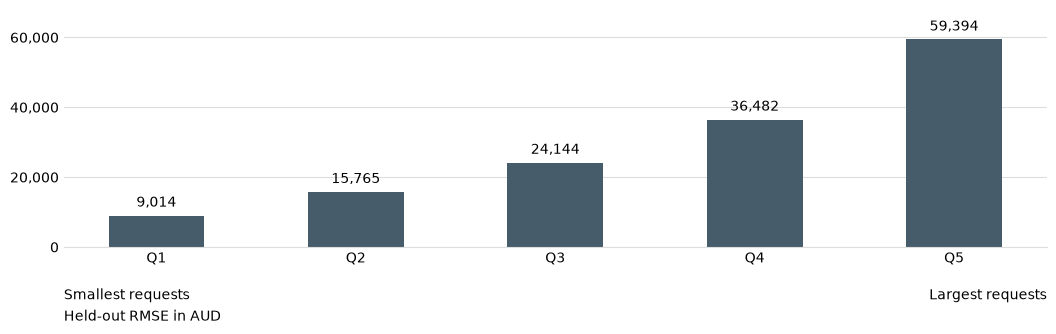

Figure saved: /Users/eric2/Documents/Data Science/S3/Applied Data Analysis/Assignment/A1/FIT-5149/report/evidence/figure_1_error_by_request.png


In [24]:
request_errors = error_tables["request_band"]
with plt.style.context("default"):
    fig, ax = plt.subplots(figsize=(10.8, 3.6))
    bars = ax.bar([f"Q{i}" for i in range(1, 6)], request_errors["rmse_aud"], color="#465C6B", width=0.48)
    ax.bar_label(bars, labels=[f"{value:,.0f}" for value in request_errors["rmse_aud"]], padding=4)
    ax.set_ylim(0, 68000)
    ax.set_yticks([0, 20000, 40000, 60000])
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#DDDDDD")
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#DDDDDD")
    ax.tick_params(length=0)
    ax.text(0, -0.22, "Smallest requests", transform=ax.transAxes, ha="left")
    ax.text(1, -0.22, "Largest requests", transform=ax.transAxes, ha="right")
    ax.text(0, -0.31, "Held-out RMSE in AUD", transform=ax.transAxes, ha="left")
    fig.subplots_adjust(left=0.08, right=0.99, top=0.94, bottom=0.28)
    figure_path = EVIDENCE_DIR / "figure_1_error_by_request.png"
    fig.savefig(figure_path, dpi=160, facecolor="white")
    plt.show()
print("Figure saved:", figure_path)

## 11. Compare single CatBoost, attempt 4 and attempt 5

The older `final_clean` used a single CatBoost regressor to predict sanction rate across all applications. We reproduce that model here as a comparison, not as the final model.

Attempt 5 uses three pairs of models with seeds 42, 73 and 2026. We average their complete dollar predictions, not the two stages separately. The functions for that candidate are kept below so its result is also reproducible from this notebook.

In [25]:
def fit_single_catboost(features, amounts):
    rates = (np.asarray(amounts) / features["requested_amount_aud"].to_numpy()).round(2)
    model = CatBoostRegressor(iterations=1200, learning_rate=0.03, depth=7,
        loss_function="RMSE", l2_leaf_reg=5.0, random_seed=42, thread_count=6,
        verbose=False, allow_writing_files=False)
    model.fit(features, rates, cat_features=MODEL_CATEGORIES)
    return model

def predict_single_catboost(model, features):
    requests = features["requested_amount_aud"].to_numpy()
    return np.clip(requests * np.clip(model.predict(features), 0, 1), 0, requests)

In [26]:
CANDIDATE_CONFIG = {'seeds': [42, 73, 2026], 'approval_iterations': 1200, 'weight_power': 0}

def fit_candidate(features, amounts, categories, config):
    # All fitting and weighting use this training fold only.
    requested = features["requested_amount_aud"].to_numpy()
    rates = (np.asarray(amounts) / requested).round(2)
    approved = np.asarray(amounts) > 0
    members = []
    for seed in config["seeds"]:
        shared = dict(learning_rate=0.03, l2_leaf_reg=10.0, random_seed=seed,
                      thread_count=6, verbose=False, allow_writing_files=False)
        approval_options, rate_options = {}, {}
        if config["weight_power"]:
            weights = requested ** config["weight_power"]
            approval_options["sample_weight"] = weights / weights.mean()
            rate_options["sample_weight"] = weights[approved] / weights[approved].mean()
        if config.get("approval_objective") == "squared":
            approval = CatBoostRegressor(loss_function="RMSE", depth=config["approval_depth"],
                                        iterations=config["approval_iterations"], **shared)
        else:
            approval = CatBoostClassifier(loss_function="Logloss", depth=5,
                                         iterations=config["approval_iterations"], **shared)
        approval.fit(features, approved.astype(int), cat_features=categories, **approval_options)
        rate = CatBoostRegressor(loss_function="RMSE", depth=4, iterations=800, **shared)
        rate.fit(features.loc[approved], rates[approved], cat_features=categories, **rate_options)
        members.append((approval, rate))
    return members


def predict_candidate(members, features):
    # Average the complete dollar predictions, not the two stages separately.
    requested = features["requested_amount_aud"].to_numpy()
    predictions = []
    for approval, rate in members:
        if isinstance(approval, CatBoostClassifier):
            positive_column = list(approval.classes_).index(1)
            probability = approval.predict_proba(features)[:, positive_column]
        else:
            probability = np.clip(approval.predict(features), 0, 1)
        positive_rate = np.clip(rate.predict(features), 0, 1)
        predictions.append(requested * probability * positive_rate)
    return np.clip(np.mean(predictions, axis=0), 0, requested)

In [27]:
def evaluate_catboost(name, fit_function, predict_function, split_seed):
    check_folds = list(StratifiedKFold(5, shuffle=True, random_state=split_seed).split(X_selected, strata))
    predictions = np.full(len(train), np.nan)
    rows = []
    for fold_number, (fit_index, valid_index) in enumerate(check_folds, 1):
        model = fit_function(X_selected.iloc[fit_index], y.iloc[fit_index])
        prediction = predict_function(model, X_selected.iloc[valid_index])
        predictions[valid_index] = prediction
        rows.append({"fold": fold_number, "rmse_aud": rmse(y.iloc[valid_index], prediction),
                     "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction)})
        print(f"{name}, split {split_seed}, fold {fold_number}: {rows[-1]['rmse_aud']:,.2f}", flush=True)
    assert np.isfinite(predictions).all()
    details = pd.DataFrame(rows)
    return {"name": name, "split_seed": split_seed, "folds": details, "oof": predictions,
            "mean_fold_rmse_aud": details["rmse_aud"].mean(),
            "sd_fold_rmse_aud": details["rmse_aud"].std(),
            "global_oof_rmse_aud": rmse(y, predictions),
            "mae_aud": mean_absolute_error(y, predictions)}

def fit_seed_average(features, amounts):
    return fit_candidate(features, amounts, MODEL_CATEGORIES, CANDIDATE_CONFIG)

catboost_results = {}
# Reuse the attempt 4 predictions already calculated in section 9.
catboost_results[("Two-stage CatBoost", 42)] = {
    "name": "Two-stage CatBoost", "split_seed": 42,
    "folds": validation_detail.copy(), "oof": final_oof.copy(),
    **validation_summary.drop("validation_seconds").to_dict(),
}
for split_seed in [42, 2026]:
    for name, fit_function, predict_function in [
        ("Single CatBoost", fit_single_catboost, predict_single_catboost),
        ("Two-stage CatBoost", fit_final_model, predict_final_model),
        ("Three-seed average", fit_seed_average, predict_candidate),
    ]:
        if (name, split_seed) not in catboost_results:
            catboost_results[(name, split_seed)] = evaluate_catboost(name, fit_function, predict_function, split_seed)

Single CatBoost, split 42, fold 1: 32,580.51


Single CatBoost, split 42, fold 2: 34,577.50


Single CatBoost, split 42, fold 3: 35,096.29


Single CatBoost, split 42, fold 4: 33,019.45


Single CatBoost, split 42, fold 5: 35,225.02


...

Three-seed average, split 2026, fold 1: 32,618.20


Three-seed average, split 2026, fold 2: 34,568.17


Three-seed average, split 2026, fold 3: 33,737.64


Three-seed average, split 2026, fold 4: 35,180.73


Three-seed average, split 2026, fold 5: 34,302.86


## 12. Gather the report's model tables

All numbers in these tables come from the fitting code above. We report mean fold RMSE, which is slightly different from RMSE over all OOF predictions combined. The second partition uses the same applications with different fold membership. It is a stability check, not independent test evidence.

The attempts were made at different points in development. The historical attempt 1 log records a CV score of 35,956. The current rerun rounds to the same value. Some intermediate report notes used older saved RF and tier-HGB scores; section 16 flags any values that still need updating in Word.

In [28]:
comparison_table = pd.DataFrame({"Mean fold RMSE AUD": [
    initial_validation_summary.loc["Ridge", "mean_constrained_rmse_aud"],
    property_ref_summary.loc["Without property_ref", "mean_rmse_aud"],
    rate_validation_summary.loc["Rate HGB", "mean_rmse_aud"],
    tier_validation_summary.loc["Tier HGB - expected rate", "mean_rmse_aud"],
    catboost_results[("Single CatBoost", 42)]["mean_fold_rmse_aud"],
    catboost_results[("Two-stage CatBoost", 42)]["mean_fold_rmse_aud"],
    catboost_results[("Three-seed average", 42)]["mean_fold_rmse_aud"],
]}, index=["Ridge with prediction bounds", "Random Forest without property_ref", "HGB sanction rate", "HGB expected sanction tier", "Single CatBoost", "Two-stage CatBoost (attempt 4)", "Three-seed average (attempt 5)"])
show_table("table_3_model_comparison", comparison_table)

stability_table = pd.DataFrame({
    name: {seed: catboost_results[(name, seed)]["mean_fold_rmse_aud"] for seed in [42, 2026]}
    for name in ["Single CatBoost", "Two-stage CatBoost", "Three-seed average"]
}).rename_axis("Partition seed")
show_table("table_4_partition_stability", stability_table)

paired_rows = []
for seed in [42, 2026]:
    single = catboost_results[("Single CatBoost", seed)]["folds"].set_index("fold")["rmse_aud"]
    two_stage = catboost_results[("Two-stage CatBoost", seed)]["folds"].set_index("fold")["rmse_aud"]
    for fold_number in single.index:
        paired_rows.append({"split_seed": seed, "fold": fold_number, "single_rmse": single[fold_number],
                            "two_stage_rmse": two_stage[fold_number], "change_aud": two_stage[fold_number] - single[fold_number]})
show_table("paired_fold_comparison", pd.DataFrame(paired_rows))

catboost_fold_tables = []
for (name, seed), result in catboost_results.items():
    details = result["folds"].assign(model=name, split_seed=seed)
    catboost_fold_tables.append(details)
show_table("catboost_comparison_folds", pd.concat(catboost_fold_tables, ignore_index=True))

,Mean fold RMSE AUD
Ridge with prediction bounds,"43,305.644"
Random Forest without property_ref,"35,955.755"
HGB sanction rate,"34,812.024"
HGB expected sanction tier,"34,658.376"
Single CatBoost,"34,099.758"
Two-stage CatBoost (attempt 4),"33,958.773"
Three-seed average (attempt 5),"33,989.175"


,Single CatBoost,Two-stage CatBoost,Three-seed average
Partition seed,,,
42,"34,099.758","33,958.773","33,989.175"
2026,"34,323.403","34,119.055","34,081.519"


,split_seed,fold,single_rmse,two_stage_rmse,change_aud
0,42,1,"32,580.515","32,393.770",-186.745
1,42,2,"34,577.504","34,388.312",-189.192
2,42,3,"35,096.294","34,920.653",-175.641
3,42,4,"33,019.454","33,013.184",-6.270
4,42,5,"35,225.022","35,077.948",-147.074
5,2026,1,"32,889.143","32,709.401",-179.742
6,2026,2,"34,698.243","34,644.329",-53.914
7,2026,3,"34,209.500","33,700.867",-508.633
8,2026,4,"35,289.126","35,244.857",-44.269
9,2026,5,"34,531.003","34,295.820",-235.183


,fold,rmse_aud,mae_aud,model,split_seed
0,1,"32,393.770","16,142.532",Two-stage CatBoost,42
1,2,"34,388.312","17,043.382",Two-stage CatBoost,42
2,3,"34,920.653","17,130.083",Two-stage CatBoost,42
3,4,"33,013.184","16,508.236",Two-stage CatBoost,42
4,5,"35,077.948","17,428.521",Two-stage CatBoost,42
5,1,"32,580.515","16,473.835",Single CatBoost,42
6,2,"34,577.504","17,384.134",Single CatBoost,42
7,3,"35,096.294","17,714.004",Single CatBoost,42
8,4,"33,019.454","16,899.319",Single CatBoost,42
9,5,"35,225.022","17,865.254",Single CatBoost,42


## 13. Keep the broader search traceable

The report also mentions a bounded search of 15 later configurations. The table below is explicitly an **archived experiment log**, not another result from the current run. Each record includes the data fingerprint, settings and five fold scores. We check the fingerprint and recompute its mean from those fold scores.

To retrain the full broader search as well, change `RERUN_EXTENDED_CHECKS` to `True`. The notebook calls the existing `loan_experiments.py` fitting functions and saves a separate recheck table. This can take considerably longer, especially tier CatBoost. It does not replace the main comparisons or change the selected model.

The source for the older search stays in that helper to avoid copying every rejected model into this notebook. No archived score is used to fill Tables 1 to 6 or Figure 1.

In [29]:
sys.path.insert(0, str(DATA_DIR / "development"))
import loan_experiments as extended

combined_hash = hashlib.sha256(b"".join((DATA_DIR / name).read_bytes() for name in input_names)).hexdigest()
archive_rows = []
for name, config in extended.CONFIGS.items():
    path = DATA_DIR / "development" / "model_checks" / f"{name}_seed42.json"
    record = json.loads(path.read_text())
    assert record["data_sha256"] == combined_hash
    assert record["config"] == config
    score = np.mean([fold["rmse_aud"] for fold in record["folds"]])
    assert np.isclose(score, record["mean_fold_rmse_aud"])
    archive_rows.append({"model": name, "mean_fold_rmse_aud": score,
                         "source": str(path.relative_to(DATA_DIR)), "settings": json.dumps(config, sort_keys=True),
                         "status": "Archived run, not retrained in this section"})
show_table("archived_extended_search", pd.DataFrame(archive_rows).set_index("model"))

RERUN_EXTENDED_CHECKS = False
if RERUN_EXTENDED_CHECKS:
    extended_results = {}
    for name, config in extended.CONFIGS.items():
        extended_results[name] = evaluate_catboost(
            name,
            lambda x, y, config=config: extended.fit_model(x, y, MODEL_CATEGORIES, config),
            lambda model, x, config=config: extended.predict_amount(model, x, config),
            42,
        )
    show_table("rerun_extended_search", pd.DataFrame({name: {key: result[key] for key in ["mean_fold_rmse_aud", "global_oof_rmse_aud", "mae_aud"]} for name, result in extended_results.items()}).T)
    blend_rows = []
    for other_name in ["catboost_current", "xgboost_two_stage"]:
        prediction = 0.5 * final_oof + 0.5 * extended_results[other_name]["oof"]
        blend_rows.append({"blend_with": other_name, "weight_each": 0.5,
                           "global_oof_rmse_aud": rmse(y, prediction),
                           "change_vs_attempt4": rmse(y, prediction) - rmse(y, final_oof)})
    show_table("fixed_blend_rechecks", pd.DataFrame(blend_rows))
else:
    print("The broader search has not been retrained. Tables 1 to 6 and Figure 1 do not depend on this switch.")

,mean_fold_rmse_aud,source,settings,status
model,,,,
catboost_current,"34,099.758",development/model_checks/catboost_current_seed...,"{""depth"": 7, ""iterations"": 1200, ""kind"": ""rate...","Archived run, not retrained in this section"
catboost_shallow,"34,204.547",development/model_checks/catboost_shallow_seed...,"{""depth"": 4, ""iterations"": 1500, ""kind"": ""rate...","Archived run, not retrained in this section"
catboost_weighted,"34,606.007",development/model_checks/catboost_weighted_see...,"{""depth"": 4, ""iterations"": 1500, ""kind"": ""rate...","Archived run, not retrained in this section"
catboost_amount,"35,348.163",development/model_checks/catboost_amount_seed4...,"{""depth"": 6, ""iterations"": 1200, ""kind"": ""amou...","Archived run, not retrained in this section"
catboost_two_stage,"33,958.773",development/model_checks/catboost_two_stage_se...,"{""depth"": 5, ""iterations"": 1200, ""kind"": ""two_...","Archived run, not retrained in this section"
catboost_tiers,"34,503.692",development/model_checks/catboost_tiers_seed42...,"{""depth"": 4, ""iterations"": 1200, ""kind"": ""tier...","Archived run, not retrained in this section"
catboost_core,"34,680.706",development/model_checks/catboost_core_seed42....,"{""depth"": 5, ""feature_set"": ""core"", ""iteration...","Archived run, not retrained in this section"
catboost_two_stage_core,"34,689.040",development/model_checks/catboost_two_stage_co...,"{""depth"": 5, ""feature_set"": ""core"", ""iteration...","Archived run, not retrained in this section"
catboost_two_stage_small,"34,120.276",development/model_checks/catboost_two_stage_sm...,"{""depth"": 4, ""feature_set"": ""small"", ""iteratio...","Archived run, not retrained in this section"


The broader search has not been retrained. Tables 1 to 6 and Figure 1 do not depend on this switch.


## 14. Record Kaggle results and calculate the differences

These five public scores were confirmed by Eric and Aditya using their submission results. They are the only externally entered scores in the main report tables. We cannot calculate them from `kaggle_test_X.csv`, because the answers are hidden. The team and usernames were also confirmed by the group.

The public leaderboard covers only 20% of the test set. The private score and final rank are unknown here. We do not use the public score as a training target or tune blend weights against it.

In [30]:
kaggle_results = pd.DataFrame([
    (1, "Random Forest", 35514.14046),
    (2, "Single CatBoost rate model", 33510.57914),
    (3, "Single CatBoost, clean implementation", 33510.57914),
    (4, "Two-stage CatBoost", 33096.96156),
    (5, "Three-seed two-stage average", 33119.70974),
], columns=["Attempt", "Model", "Public RMSE AUD"]).set_index("Attempt")
show_table("table_6_kaggle_results", kaggle_results)
public4 = kaggle_results.loc[4, "Public RMSE AUD"]
score_differences = pd.Series({
    "public_improvement_attempt2_to_4": kaggle_results.loc[2, "Public RMSE AUD"] - public4,
    "public_attempt5_minus_attempt4": kaggle_results.loc[5, "Public RMSE AUD"] - public4,
    "attempt4_mean_cv_minus_public": validation_summary["mean_fold_rmse_aud"] - public4,
    "cv_gain_single_to_two_stage_split42": stability_table.loc[42, "Single CatBoost"] - stability_table.loc[42, "Two-stage CatBoost"],
    "cv_gain_single_to_two_stage_split2026": stability_table.loc[2026, "Single CatBoost"] - stability_table.loc[2026, "Two-stage CatBoost"],
    "seed_average_minus_attempt4_split42": stability_table.loc[42, "Three-seed average"] - stability_table.loc[42, "Two-stage CatBoost"],
    "seed_average_minus_attempt4_split2026": stability_table.loc[2026, "Three-seed average"] - stability_table.loc[2026, "Two-stage CatBoost"],
}, name="AUD")
show_table("score_differences", score_differences.to_frame())
team_details = {"group": 43, "team": "TEAM ERIC-ADITYA", "usernames": ["adityapalve9979", "ericacostaramirez"]}
print(team_details)

,Model,Public RMSE AUD
Attempt,,
1,Random Forest,"35,514.140"
2,Single CatBoost rate model,"33,510.579"
3,"Single CatBoost, clean implementation","33,510.579"
4,Two-stage CatBoost,"33,096.962"
5,Three-seed two-stage average,"33,119.710"


,AUD
public_improvement_attempt2_to_4,413.618
public_attempt5_minus_attempt4,22.748
attempt4_mean_cv_minus_public,861.812
cv_gain_single_to_two_stage_split42,140.985
cv_gain_single_to_two_stage_split2026,204.348
seed_average_minus_attempt4_split42,30.401
seed_average_minus_attempt4_split2026,-37.535


{'group': 43, 'team': 'TEAM ERIC-ADITYA', 'usernames': ['adityapalve9979', 'ericacostaramirez']}


## 15. Check that the model really reproduces attempt 4

Finally we train on all labelled rows and compare the resulting CSV bytes with the saved attempt 4. A matching score alone is not enough. We check the predictions, IDs, order, bounds and file content.

The recreated file stays in the evidence folder. The original `submission.csv` and attempt files are not overwritten. If this check fails, investigate the environment, input files or model code before replacing anything.

In [31]:
# Validation is finished. Fit the same model on all labelled applications.
final_model = fit_final_model(X_selected, y)
final_prediction = predict_final_model(final_model, X_kaggle_selected).round(2)
# Preserve the IDs and row order expected by Kaggle.
submission = sample_submission[["application_id"]].copy()
submission[TARGET] = final_prediction

# Check the output before writing the final CSV.
assert submission.shape == (10000, 2)
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission["application_id"].equals(test["application_id"])
assert submission["application_id"].is_unique
assert np.isfinite(submission[TARGET]).all()
assert submission[TARGET].between(0, test["requested_amount_aud"]).all()

# This is the file paired with the final notebook for attempt 4.
submission_path = EVIDENCE_DIR / "reproduced_attempt4.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved {submission_path.name}: {len(submission):,} checked predictions.")
display(submission.head())

attempt4_path = DATA_DIR / "submissions" / "submission_catboost_twostage_attempt4.csv"
assert submission_path.read_bytes() == attempt4_path.read_bytes(), "The reproduced CSV differs from attempt 4."
assert submission_path.read_bytes() == (DATA_DIR / "submission.csv").read_bytes(), "The root submission is not attempt 4."
for relative_path, expected_hash in protected_hashes.items():
    assert file_hash(DATA_DIR / relative_path) == expected_hash, f"Original changed: {relative_path}"
print("Exact attempt 4 match. All original submission files are unchanged.")

Saved reproduced_attempt4.csv: 10,000 checked predictions.


,application_id,sanctioned_amount_aud
0,LN-029039,"67,236.480"
1,LN-006880,"29,707.880"
2,LN-000529,"104,846.940"
3,LN-002049,"173,135.080"
4,LN-000921,688.330


Exact attempt 4 match. All original submission files are unchanged.


## 16. Record sources and compare the report with this run

The model results are calculated above. We now compare the report's displayed numbers with those results, not the other way around. If a report table is out of date, the table below lists the difference. We do not change a calculated score just to make it agree with the document.

The chart values and exact selected submission are also checked. Updating this notebook does not automatically update an open Word document or its appendix. The provenance record states whether the six main numeric tables in the current Word file match this run. Narrative edits still need a separate review.

In [2]:
# The final model must still match the selected attempt, including its diagnostics.
assert np.isclose(validation_summary["mean_fold_rmse_aud"], 33958.77327986962, atol=0.000001, rtol=0)
assert np.array_equal(np.rint(request_errors["rmse_aud"]).astype(int), [9014, 15765, 24144, 36482, 59394])

# Read the existing Word tables using the standard library. No document is changed.
from zipfile import ZipFile
from xml.etree import ElementTree as ET

report_path = DATA_DIR / "report" / "group43_ass1_report.docx"
document_checks = []
report_tables_match = None
report_sha256 = None
if report_path.exists():
    ns = {"w": "http://schemas.openxmlformats.org/wordprocessingml/2006/main"}
    with ZipFile(report_path) as package:
        document = ET.fromstring(package.read("word/document.xml"))
    word_tables = []
    for table in document.findall(".//w:tbl", ns):
        word_tables.append([
            ["".join(t.text or "" for t in cell.findall(".//w:t", ns)) for cell in row.findall("w:tc", ns)]
            for row in table.findall("w:tr", ns)
        ])
    by_heading = {table[0][0]: table for table in word_tables}

    def compare_number(label, recorded, calculated, decimals):
        expected_text = f"{float(calculated):,.{decimals}f}"
        recorded = recorded.replace("$", "").replace("%", "").strip()
        document_checks.append({"item": label, "Word value": recorded,
                                "Calculated value": expected_text,
                                "matches": recorded == expected_text})

    table = by_heading["Raw missing values"]
    for row in table[1:]:
        for col, value in zip(["Train missing %", "Test missing %"], row[1:]):
            compare_number(f"Missing: {row[0]}, {col}", value, missing_table.loc[row[0], col], 2)

    table = by_heading["Controlled comparison"]
    for i in range(3):
        compare_number(f"Preprocessing: {preprocessing_table.index[i]}", table[i + 1][1], preprocessing_table.iloc[i, 0], 0)
    rf_values = table[4][1].split("/")
    for i, value in enumerate(rf_values):
        compare_number(f"Preprocessing: {preprocessing_table.index[i + 3]}", value, preprocessing_table.iloc[i + 3, 0], 0)

    table = by_heading["Model or formulation"]
    assert len(table) - 1 == len(comparison_table)
    for i, row in enumerate(table[1:]):
        compare_number(f"Model: {comparison_table.index[i]}", row[1], comparison_table.iloc[i, 0], 0 if i < 4 else 2)

    table = by_heading["Partition seed"]
    for row in table[1:]:
        for name, value in zip(["Single CatBoost", "Two-stage CatBoost"], row[1:]):
            compare_number(f"Partition {row[0]}: {name}", value, stability_table.loc[int(row[0]), name], 2)

    table = by_heading["Input shuffled"]
    for i, row in enumerate(table[1:]):
        for column, value in zip(["mean", "std"], row[1:]):
            compare_number(f"Permutation: {permutation_summary.index[i]}, {column}", value, permutation_summary.iloc[i][column], 0)

    table = by_heading["Attempt"]
    for row in table[1:]:
        compare_number(f"Kaggle attempt {row[0]}", row[2], kaggle_results.loc[int(row[0]), "Public RMSE AUD"], 5)

    document_audit = pd.DataFrame(document_checks)
    show_table("word_table_audit", document_audit)
    report_tables_match = bool(document_audit["matches"].all())
    report_sha256 = file_hash(report_path)
    if report_tables_match:
        print("The six main numeric tables in Word match this run.")
    else:
        print("The report needs these numeric updates. The model calculations have not been altered:")
        display(document_audit.loc[~document_audit["matches"]])
else:
    print("Word report not present. Numeric report matching was not checked.")

versions = {"Python": sys.version.split()[0], "NumPy": np.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "CatBoost": catboost.__version__}
show_table("software_versions", pd.Series(versions, name="version").to_frame())
manifest = {
    "source_notebook": "development/FIT5149_A1_final_clean.ipynb",
    "input_sha256": input_hashes,
    "selected_model": "attempt4_two_stage_catboost",
    "main_results_retrained": True,
    "broader_search_retrained": RERUN_EXTENDED_CHECKS,
    "original_submissions_unchanged": True,
    "exact_attempt4_csv_match": True,
    "prediction_sha256": file_hash(submission_path),
    "word_report_sha256": report_sha256,
    "word_numeric_tables_match": report_tables_match,
    "software": versions,
    "kaggle_source": "Public scores confirmed by the team from submission results, not locally calculated",
    "team": team_details,
    "table_files": [f"{name}.csv" for name in report_tables],
    "figure_file": figure_path.name,
}
# Saving execution outputs does not change this source-code fingerprint.
source_notebook = json.loads(this_notebook.read_text())
code_source = "\n".join("".join(c["source"]) for c in source_notebook["cells"] if c["cell_type"] == "code")
manifest["notebook_code_sha256"] = hashlib.sha256(code_source.encode()).hexdigest()
(EVIDENCE_DIR / "provenance.json").write_text(json.dumps(manifest, indent=2) + "\n")
print("Evidence exported to:", EVIDENCE_DIR)


,item,Word value,Calculated value,matches
0,"Missing: property_age_years, Train missing %",32.40,32.40,True
1,"Missing: property_age_years, Test missing %",32.62,32.62,True
2,"Missing: monthly_income_aud, Train missing %",25.69,25.69,True
3,"Missing: monthly_income_aud, Test missing %",24.84,24.84,True
4,"Missing: annual_income_aud, Train missing %",25.09,25.09,True
5,"Missing: annual_income_aud, Test missing %",24.85,24.85,True
6,"Missing: employment_sector, Train missing %",24.36,24.36,True
7,"Missing: employment_sector, Test missing %",24.19,24.19,True
8,"Missing: credit_rating, Train missing %",20.46,20.46,True
9,"Missing: credit_rating, Test missing %",21.33,21.33,True


The report needs these numeric updates. The model calculations have not been altered:


,item,Word value,Calculated value,matches
13,Preprocessing: RF with property_ref,"35,973","35,994",False
14,Preprocessing: RF without property_ref,"35,965","35,956",False
16,Model: Random Forest without property_ref,"35,965","35,956",False
18,Model: HGB expected sanction tier,"34,625","34,658",False


,version
Python,3.11.15
NumPy,2.4.6
pandas,3.0.5
scikit-learn,1.9.0
CatBoost,1.2.10


Evidence exported to: /Users/eric2/Documents/Data Science/S3/Applied Data Analysis/Assignment/A1/FIT-5149/report/evidence
